<a href="https://colab.research.google.com/github/NehaSrinivas98/MachineLearningCourse/blob/main/CourseContents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Missing values
## Types of missing values
* Missing Completely at Random (MCAR)
* Missing at Random (MAR)
* Missing Not at Random (MNAR)

##a. Missing Completely at Random (MCAR)

Data is missing completely randomly, and the missingness is not related to any variable in the dataset.

Example:
* A survey form gets damaged and some responses are lost.
* A sensor randomly fails to record temperature.

Characteristics:
* Missing values have no pattern.
* The missingness is independent of both observed and unobserved data.

Impact:
* Least problematic.
* You can safely use methods like listwise deletion or mean/median imputation.

##b. Missing at Random (MAR)

Missing data depends on other observed variables, but not on the missing value itself.
Example:
* Older people are less likely to reveal their income in a survey.
* Income is missing because of age, which is available in the dataset.
Characteristics:
* Missingness has a pattern related to another variable.
Impact Can be handled using:
* Regression imputation
* Multiple imputation
* Machine learning models

##c. Missing Not at Random (MNAR)

Missingness depends on the missing value itself.

Example:

* People with very high income refuse to disclose their salary.

* The probability of missing data depends on the actual income value.

Characteristics:

* Hardest type to handle.

* Missing data has a systematic bias.

Impact:

* Requires advanced modeling or domain knowledge.

# Handling missing values
##a. Delete Rows (Listwise Deletion)

* Remove rows that contain missing values.

* Example
<table>
  <tr>
    <th>
      Age
    </th>
    <th>
     Salary
    </th>
  </tr>
  <tr>
    <td>
      25
    </td>
    <td>
      40000
    </td>
  </tr>
  <tr>
    <td>
      30
    </td>
    <td>
      50000
    </td>
  </tr>
  <tr>
    <td>
      20
    </td>
    <td>
      Null
    </td>
  </tr>
</table>

* Use when the dataset is large missing values are very few and data is mcar
* Risk is loss of information

##b. Delete Columns
* Remove the entire column if too many values are missing.
* Use when Missing values > 40–50% and column is not important
* Example:
A column like middle_name may be removed.

##c. Mean Imputation
* Replace missing values with the mean of the column.
* Example:
20, 25, NaN, 30 ( mean = 25) replace nan with 25
* Use when Data is numerical and Distribution is normal

##d. Median Imputation
* Replace missing values with the median.
* Example: 30000,35000,Nan,900000 replace with median value 35000
* Use when Data has outliers and Median is more robust than mean.

##e. Mode Imputation
* Replace missing values with the most frequent value.
* Example:Male, Female, Male, NaN replace with Mode value Male
* Use when it is Categorical data

##f. Forward Fill (FFill)
* Use the previous value to fill missing data.
* Example: 100,Nan, 200 Fill with 100 value
*  Used in Time series data and stock prices

##g. Backward Fill (BFill)
* Use the next available value.
* Example: 100,Nan, 200 Fill with 200 value


##h. Interpolation
* Estimate missing values using a mathematical relationship between surrounding values.
* Example: 1, 2, NaN, 4 (Interpolated → 3)
* Common in Sensor data and Time series

##i. Predict Missing Values Using ML
* Use machine learning models to predict missing values.
* Example: Predict salary using the other features
* Models used is regression,decision trees,random forest

##j. Multiple Imputation
* Create multiple estimates for missing values and average them.
* Used in advanced statistical modeling.

#2. Imbalanced dataset
An imbalanced dataset occurs when the number of observations in different classes is not equal, especially in classification problems.

This situation is called Class Imbalance.

Handling imbalanced dataset
#a. Upsampling (Oversampling)

Increase the number of minority class samples.

Example:
* Duplicate minority samples
* Generate synthetic data
* One popular technique is Synthetic Minority Over-sampling Technique (SMOTE).

#b. Downsampling (Undersampling)

Reduce the number of majority class samples.

#c. Class Weighting

Give higher penalty to minority class errors.

Example in Python:

class_weight='balanced'

Used in models like:

* Logistic Regression

* Random Forest

* SVM

#d. Ensemble Methods
* An ensemble method combines multiple models to improve prediction performance.
* This concept is called Ensemble Learning.
* Instead of using one model, we combine many models.

* Use specialized algorithms such as Balanced Random Forest
EasyEnsemble

In [16]:
# Example for upsampling
import numpy as np
import pandas as pd # Set the random seed for reproducibility
np.random.seed(123) # Create a dataframe with two classes
n_samples = 1000
class_0_ratio = 0.9
n_class_0 = int(n_samples * class_0_ratio)
n_class_1 = n_samples - n_class_0
print('n_class_0',n_class_0)
print('n_class_1',n_class_1)

n_class_0 900
n_class_1 100


* A seed is used to control randomness so that results can be reproduced.
* In programming and Machine Learning, many operations use random numbers, such as:

1. Data shuffling

2. Train-test splitting

3. Weight initialization in models

4. Random sampling

* Setting a seed ensures that the same random numbers are generated every time the program runs.

In [4]:
## CREATE MY DATAFRAME WITH IMBALANCED DATASET
class_0 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0, scale=1, size=n_class_0), # loc means 0 and scale means SD
    'feature_2': np.random.normal(loc=0, scale=1, size=n_class_0),
    'target': [0] * n_class_0 # generates 900 0's
})

class_1 = pd.DataFrame({
    'feature_1': np.random.normal(loc=2, scale=1, size=n_class_1),
    'feature_2': np.random.normal(loc=2, scale=1, size=n_class_1),
    'target': [1] * n_class_1 # generates 100 1's
})
print('class0',class_0)
print('class1',class_1)

class0      feature_1  feature_2  target
0    -0.471276   0.328462       0
1     1.084072   1.038230       0
2    -0.379223   1.147064       0
3    -0.362274   0.638254       0
4    -0.681071  -1.075766       0
..         ...        ...     ...
895  -0.229982  -1.433189       0
896  -0.533514  -0.370110       0
897   0.060924  -0.284352       0
898   1.041367   0.373888       0
899  -0.862830   0.263030       0

[900 rows x 3 columns]
class1     feature_1  feature_2  target
0    1.775921   0.902553       1
1    2.338840   1.058241       1
2    1.728472   3.670939       1
3    3.365531   2.067791       1
4    1.262626   3.630785       1
..        ...        ...     ...
95   2.720690   1.978489       1
96   1.949078   3.709793       1
97   2.709784   3.324917       1
98   1.817689   1.549237       1
99   2.838910   2.240773       1

[100 rows x 3 columns]


In [5]:
df=pd.concat([class_0,class_1]).reset_index(drop=True)

In [6]:
df.tail()

,feature_1,feature_2,target
995,2.720690,1.978489,1
996,1.949078,3.709793,1
997,2.709784,3.324917,1
998,1.817689,1.549237,1
999,2.838910,2.240773,1


In [7]:
df['target'].value_counts()

,count
target,
0,900
1,100


In [8]:
df_minority=df[df['target']==1]
df_majority=df[df['target']==0]

In [9]:
from sklearn.utils import resample
df_minority_upsampled=resample(df_minority,replace=True, #Sample With replacement
         n_samples=len(df_majority),
         random_state=42
        )

In [11]:
df_minority_upsampled.shape

(900, 3)

In [12]:
df_majority.shape

(900, 3)

In [14]:
df_upsampled=pd.concat([df_majority,df_minority_upsampled])

In [15]:
df_upsampled['target'].value_counts()

,count
target,
0,900
1,900


In [39]:
# Downsampling
import pandas as pd

# Set the random seed for reproducibility
np.random.seed(123)

# Create a dataframe with two classes
n_samples = 1000
class_0_ratio = 0.9
n_class_0 = int(n_samples * class_0_ratio)
n_class_1 = n_samples - n_class_0

class_0 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0, scale=1, size=n_class_0),
    'feature_2': np.random.normal(loc=0, scale=1, size=n_class_0),
    'target': [0] * n_class_0
})

class_1 = pd.DataFrame({
    'feature_1': np.random.normal(loc=2, scale=1, size=n_class_1),
    'feature_2': np.random.normal(loc=2, scale=1, size=n_class_1),
    'target': [1] * n_class_1
})

df = pd.concat([class_0, class_1]).reset_index(drop=True)

# Check the class distribution
print(df['target'].value_counts())

target
0    900
1    100
Name: count, dtype: int64


In [40]:
df_minority=df[df['target']==1]
df_majority=df[df['target']==0]

In [41]:
df_majority_downsampled = resample(
    df_majority,
    replace=False,      # sample without replacement
    n_samples=len(df_minority),
    random_state=42
)

# combine datasets
df_balanced = pd.concat([df_majority_downsampled, df_minority])

In [42]:
df_balanced['target'].value_counts()

,count
target,
0,100
1,100


Smote
* SMOTE (Synthetic Minority Over-sampling Technique) is a data augmentation method used in machine learning to address class imbalance—a scenario where one category in a dataset (the majority) significantly outnumbers another (the minority).

* Unlike simple oversampling, which just duplicates existing records, SMOTE creates new, synthetic samples for the minority class to help models learn its patterns more effectively.

* 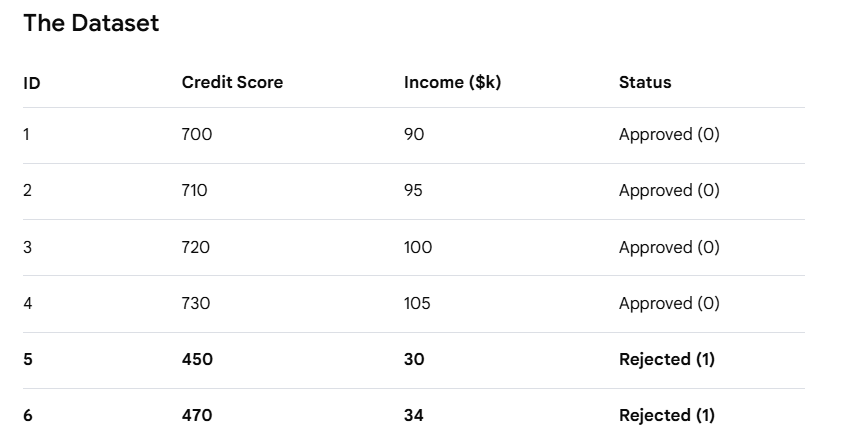
* Instead of just copying point 5 or 6, SMOTE draws a line between them and picks a random spot. The formula is:

 Synthetic = PointA + random(0,1)* (PointB- PointA)
 1. Select Point A: (450, 30)
 2. Select Point B (a neighbor): (470, 34)
 3. Calculate Difference: (470-450=20,34-30=4)
 4. Create a new point: Suppose random = 0.4 then new record is 450+(0.4*20) = 458 for credit and 30+(0.4*4) = 31.6 for income
 5. Similar way multiple points will be generated with the help of different randoms

Variants of smote
To make these clear, let’s use a tiny Credit Card Fraud dataset with 100 Legit transactions and 10 Fraud transactions.
1. Borderline-SMOTE: The "Edge Finder"

* The Problem: Normal SMOTE creates synthetic data for all 10 frauds, even the "obvious" ones.

* The Example: 8 of your fraud cases are clearly suspicious. 2 are "borderline" (they look almost like legit purchases).

* The Action: Borderline-SMOTE ignores the 8 obvious ones and creates all 90 new synthetic points around those 2 "borderline" cases to help the model learn the tricky difference.
2. ADASYN: The "Difficulty Specialist"
* The Problem: Some fraud cases are harder to catch than others.
* The Example: You have one fraud case surrounded by 10 legit transactions (very hard to spot). You have another fraud case surrounded by only 2 legit transactions (easier).
* The Action: ADASYN will generate more synthetic points around the "hard" fraud case and fewer around the "easy" one, forcing the model to study the difficult area more.
3. SMOTE-NC: The "Categorical Mixer"
* The Problem: You can't "average" a Transaction Type like Online and In-Store.
* The Example: Fraud A is $50 and Online. Fraud B is $100 and Online.
* The Action: It averages the math  but keeps the category Online (the most common among neighbors) rather than trying to create a non-existent "half-online" category.
4. SMOTE-Tomek: The "Cleaner"
* The Problem: SMOTE sometimes creates a "smudge" where fraud and legit points overlap.
* The Example: SMOTE creates a synthetic fraud point that is mathematically almost identical to a legit point.
* The Action: SMOTE-Tomek finds these "too-close" pairs (Tomek Links) and deletes both. This creates a clear "no-man's land" between classes so the model doesn't get confused.
5. K-Means SMOTE: The "Cluster Focus"
* The Problem: Fraud often happens in specific "zones" (e.g., high-value electronics or small gas station tests).
* The Example: You have two clusters of fraud: one at 2 AM and one for $500+ purchases.
* The Action: It groups the data into these two clusters first. It then generates synthetic data only inside those clusters, preventing it from creating "random" fraud points in areas where fraud never actually happens.